<h1>Objective</h1>

<h3>To apply data augmentation on folder and see if accuracy has improved or not</h3>

In [3]:
dataset_path = r"C:\Users\INDIA\Documents\Deep-Learning\archive"

creating generators

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

training data

In [19]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

#flow_from_directory:

# The augmentation happens on the fly:


# Original Image
#       ↓
# Random Augmentation
#       ↓
# Sent directly to CNN
#       ↓
# Discarded


# the augmented images are not automatically stored anywhere

Found 3502 images belonging to 4 classes.


So:

original dataset remains unchanged
no new image files are created 
images are generated in memory for each batch during training

validation data

In [6]:
val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 874 images belonging to 4 classes.


In [7]:
#checking class mapping

In [8]:
print(train_generator.class_indices)

{'paper': 0, 'rock': 1, 'rps-cv-images': 2, 'scissors': 3}


In [ ]:
#building CNN

In [15]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential()

model.add(Input(shape=(150,150,3)))

model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(4,activation='softmax'))

In [16]:
#compiling

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,828,868 (18.42 MB)

 Trainable params: 4,828,868 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 76s 678ms/step - accuracy: 0.4943 - loss: 1.2499 - val_accuracy: 0.4966 - val_loss: 1.1696
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 46s 419ms/step - accuracy: 0.4946 - loss: 1.1055 - val_accuracy: 0.5160 - val_loss: 1.0145
Epoch 3/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 47s 426ms/step - accuracy: 0.4803 - loss: 1.0289 - val_accuracy: 0.5149 - val_loss: 0.9649
Epoch 4/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 47s 430ms/step - accuracy: 0.5009 - loss: 0.9734 - val_accuracy: 0.3833 - val_loss: 1.0053
Epoch 5/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 45s 412ms/step - accuracy: 0.5171 - loss: 0.9121 - val_accuracy: 0.3364 - val_loss: 0.9757
Epoch 6/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 45s 412ms/step - accuracy: 0.5246 - loss: 0.8780 - val_accuracy: 0.2517 - val_loss: 0.9686
Epoch 7/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 49s 443ms/step - accuracy: 0.5451 - loss: 0.8182 - val_accuracy: 0.2220 - val_loss: 0.9273
Epoch 8/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 66s 602ms/step - accuracy: 0.5408 - loss: 0

In [20]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,486,606 (55.26 MB)

 Trainable params: 4,828,868 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,657,738 (36.84 MB)

<h1>Model without augmentation</h1>

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen_no_aug = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_no_aug = datagen_no_aug.flow_from_directory(
    dataset_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_no_aug = datagen_no_aug.flow_from_directory(
    dataset_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 3502 images belonging to 4 classes.
Found 874 images belonging to 4 classes.


In [22]:
#making sure the output layer matches my classes

num_classes = train_no_aug.num_classes
print(num_classes)

4


In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

model1 = Sequential([
    Input(shape=(150,150,3)),

    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D(),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(),

    Flatten(),

    Dense(128,activation='relu'),

    Dense(num_classes,activation='softmax')
])

model1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
history_no_aug = model1.fit(
    train_no_aug,
    validation_data=val_no_aug,
    epochs=10
)

Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 30s 263ms/step - accuracy: 0.4894 - loss: 1.2158 - val_accuracy: 0.4027 - val_loss: 0.9745
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 31s 284ms/step - accuracy: 0.5197 - loss: 0.8477 - val_accuracy: 0.2963 - val_loss: 0.9784
Epoch 3/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 30s 272ms/step - accuracy: 0.5280 - loss: 0.7907 - val_accuracy: 0.2471 - val_loss: 1.0168
Epoch 4/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 30s 272ms/step - accuracy: 0.5348 - loss: 0.7552 - val_accuracy: 0.3112 - val_loss: 1.0224
Epoch 5/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 30s 273ms/step - accuracy: 0.5477 - loss: 0.7306 - val_accuracy: 0.2597 - val_loss: 1.0627
Epoch 6/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 30s 272ms/step - accuracy: 0.5477 - loss: 0.7211 - val_accuracy: 0.3318 - val_loss: 0.9375
Epoch 7/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 30s 271ms/step - accuracy: 0.5428 - loss: 0.7119 - val_accuracy: 0.2654 - val_loss: 0.9667
Epoch 8/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 31s 286ms/step - accuracy: 0.5603 - loss: 0

<h2>Compare Validation Accuracy</h2>

In [25]:
print("Without Augmentation:",
      max(history_no_aug.history['val_accuracy']))

print("With Augmentation:",
      max(history.history['val_accuracy']))

Without Augmentation: 0.4027459919452667
With Augmentation: 0.5160183310508728


<h3>We can clearly see with data augmentation val_accuracy has increased</h3>

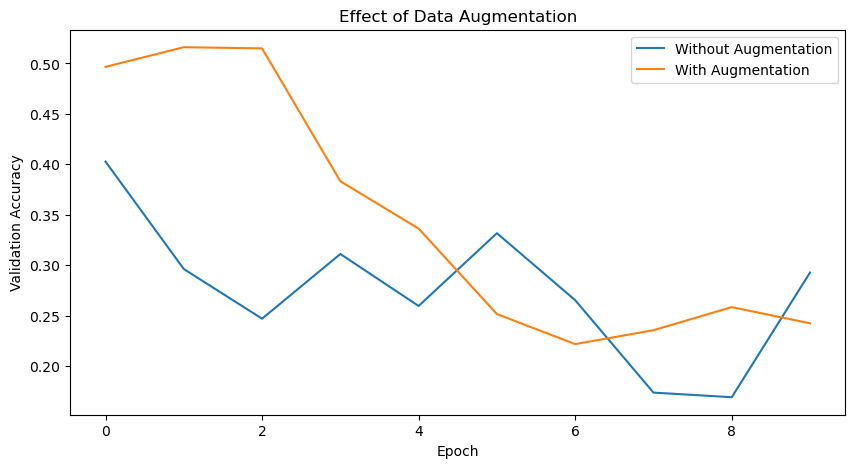

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    history_no_aug.history['val_accuracy'],
    label='Without Augmentation'
)

plt.plot(
    history.history['val_accuracy'],
    label='With Augmentation'
)

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Effect of Data Augmentation')
plt.legend()

plt.show()

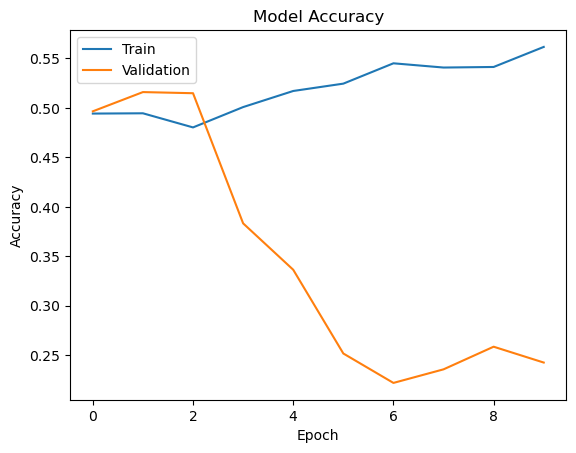

In [27]:


plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train','Validation'])

plt.show()